Dynamic stock model of DRI

In [ ]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
from electrolysers.raw_processing.dynamic_stock_model import DynamicStockModel

Load data

In [35]:
# Path to data (have to fix this)
path = r'C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\DRI_scenarios.csv'

# Load data in dataframe
DRI_scenarios = pd.read_csv(path)

# Look at the data
display(DRI_scenarios.head())

,Year,Total DRI [Mt],DRI_SSP1,DRI_SSP2,DRI_SSP3,DRI_SSP5
0,1971,0.95,NaN,NaN,NaN,NaN
1,1972,1.39,NaN,NaN,NaN,NaN
2,1973,1.90,NaN,NaN,NaN,NaN
3,1974,2.72,NaN,NaN,NaN,NaN
4,1975,2.81,NaN,NaN,NaN,NaN


Prepare data for DSM

In [156]:
# Define vector for historic data in total DRI column from 1971 to 2024
historic_data = DRI_scenarios.loc[DRI_scenarios['Year'].between(1971, 2024), 'Total DRI [Mt]'].values / 0.8
years = np.arange(1950, 2051)

# Define vector for each scenario with projected data from 2025 to 2050
stock_SSP1 = DRI_scenarios.loc[DRI_scenarios['Year'].between(2025, 2050), 'DRI_SSP1'].values
stock_SSP2 = DRI_scenarios.loc[DRI_scenarios['Year'].between(2025, 2050), 'DRI_SSP2'].values
stock_SSP3 = DRI_scenarios.loc[DRI_scenarios['Year'].between(2025, 2050), 'DRI_SSP3'].values
stock_SSP5 = DRI_scenarios.loc[DRI_scenarios['Year'].between(2025, 2050), 'DRI_SSP5'].values

# Add historic data and projected data together for each scenario
s_SSP1 = np.concatenate((historic_data, stock_SSP1))
s_SSP2 = np.concatenate((historic_data, stock_SSP2))
s_SSP3 = np.concatenate((historic_data, stock_SSP3))
s_SSP5 = np.concatenate((historic_data, stock_SSP5))

# New data with zeros in the start
#s_SSP1 = np.concatenate((np.zeros(len(years) - len(s_SSP1)), s_SSP1))

In [128]:
# Define logistic regression function
def logistic(x:np.ndarray,ti:float,tau:float,C0:float,C1:float) -> np.ndarray:
    return (C1 - C0)/(1 + np.exp(-(x - ti) / tau)) + C0

In [160]:
# Define x and y for curve fitting
x_data = np.arange(1971, 2051)
y_data = s_SSP1 * 1000

display(y_data)

array([  1187.5       ,   1737.5       ,   2375.        ,   3400.        ,
         3512.5       ,   3775.        ,   4400.        ,   6250.        ,
         8300.        ,   8925.        ,   9900.        ,   9100.        ,
         9875.        ,  11675.        ,  13962.5       ,  15662.5       ,
        16900.        ,  17612.5       ,  19537.5       ,  22100.        ,
        24150.        ,  25637.5       ,  29562.5       ,  34212.5       ,
        38337.5       ,  41625.        ,  45237.5       ,  46200.        ,
        48250.        ,  54725.        ,  50400.        ,  56350.        ,
        61812.5       ,  68250.        ,  71087.5       ,  74625.        ,
        83900.        ,  84937.5       ,  80412.5       ,  87850.        ,
        91512.5       ,  91425.        ,  93650.        ,  93237.5       ,
        90800.        ,  90950.        , 108875.        , 125912.5       ,
       135125.        , 131050.        , 148950.        , 159200.        ,
       169662.5       , 1

In [161]:
# Fit the logistic function to the data to interpolate and extrapolate data
popt, pcov = curve_fit(
    logistic,
    x_data,
    y_data,
    bounds=([min(x_data), 0, 0, 0], [max(x_data), 10**6, 10**5, 10**6]),
    maxfev=1000000
)

# Extract fitted parameters
ti_fit, tau_fit, C0_fit, C1_fit = popt

# Predict values using the fitted parameters
pred_outputs = logistic(years, *popt)

print(f"Logistic fit parameters: ti={ti_fit}, tau={tau_fit}, C0={C0_fit}, C1={C1_fit}")

Logistic fit parameters: ti=2042.4226659777923, tau=10.609066315200572, C0=20765.384246062255, C1=999999.9999999995


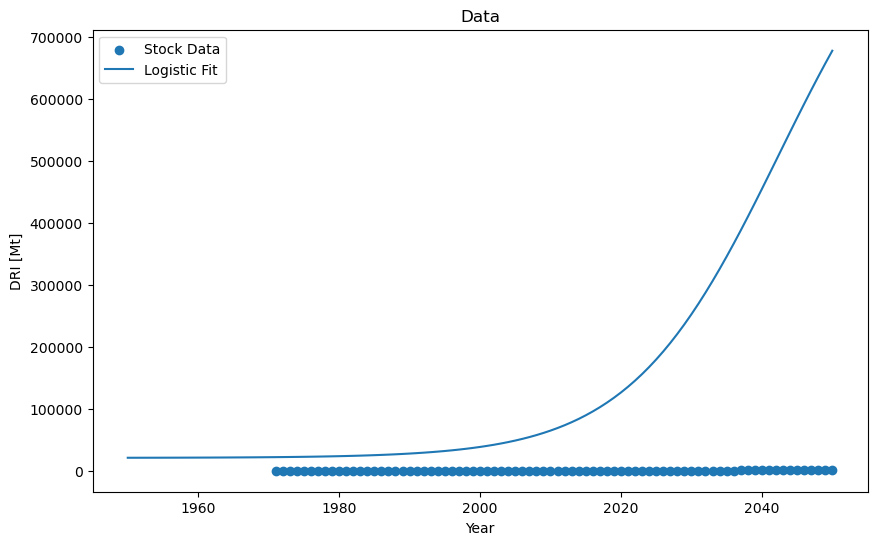

array([ 20926.59195812,  20942.52354097,  20960.02927228,  20979.26462369,
        21000.40040858,  21023.62429326,  21049.14245627,  21077.18141053,
        21107.99000381,  21141.84161517,  21179.03656599,  21219.90476665,
        21264.8086213 ,  21314.14621565,  21368.35481488,  21427.91470139,
        21493.35338445,  21565.25021749,  21644.24146097,  21731.02583323,
        21826.37059449,  21931.11821388,  22046.1936731 ,  22172.61246519,
        22311.48935153,  22464.0479454 ,  22631.63119573,  22815.71285057,
        23017.90998524,  23239.99668674,  23483.91899177,  23751.81118215,
        24046.01354768,  24369.09173231,  24723.85778537,  25113.39304439,
        25541.07298065,  26010.5941412 ,  26526.00332288,  27091.72911297,
        27712.61592797,  28393.96067484,  29141.55214847,  29961.71326199,
        30861.3461842 ,  31847.98042693,  32929.82388459,  34115.81677613,
        35415.68837335,  36840.01631784,  38400.28822721,  40108.965169  ,
        41979.54643217,  

In [162]:
# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(x_data, s_SSP1, label='Stock Data')
plt.plot(years, pred_outputs, label='Logistic Fit')
plt.xlabel('Year')
plt.ylabel('DRI [Mt]')
plt.title('Data')
plt.legend()
plt.show()

display(pred_outputs)

Stock driven model

In [163]:
t = years
s = pred_outputs

# Lifetime distribution
lt = {
    'Type': 'Normal',
    'Mean': np.full(len(t), 40),
    'StdDev': np.full(len(t), 10)
}

dsm = DynamicStockModel(t = t, s = s, lt = lt)

s_c1, o_c1, i1 = dsm.compute_stock_driven_model(NegativeInflowCorrect = False)

#Compute outflow by cohort from stock by cohort.
o_c1 = dsm.compute_o_c_from_s_c()

#Determine total outflow as row sum of cohort-specific outflow.
o1 = dsm.compute_outflow_total()

#Determine stock change from time series for stock. Formula: stock_change(t) = stock(t) - stock(t-1).
stock_change1 = dsm.compute_stock_change()

Look at results

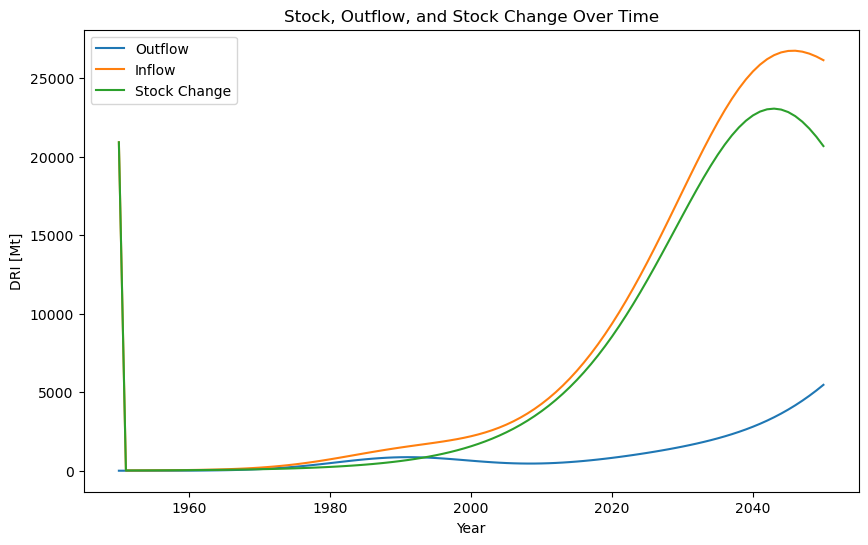

In [164]:
# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(t, s, label='Stock')
plt.plot(years, o1, label='Outflow')
plt.plot(years, i1, label='Inflow')
plt.plot(years, stock_change1, label='Stock Change')
plt.xlabel('Year')
plt.ylabel('DRI [Mt]')
plt.title('Stock, Outflow, and Stock Change Over Time')
plt.legend()
plt.show()